<Axes: xlabel='time'>

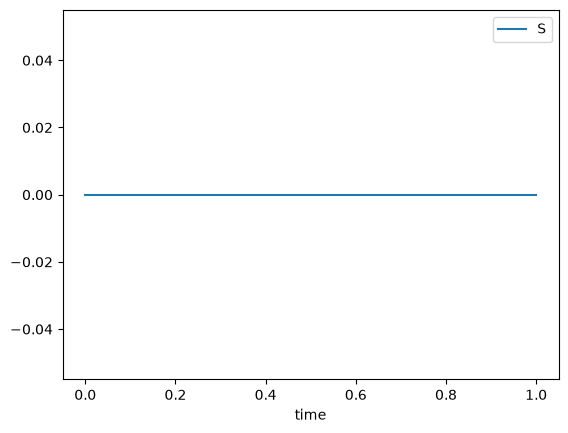

In [17]:
import numpy as np
from poincare import *
import pint

u = pint.get_application_registry()

class Laser(System):
    t = Independent()
    S = initial(default = 0)
    N = initial(default = 0)

    P = assign(default = 2)
    G = assign(default = 0.5)
    tau_c = assign(default = 1.0)
    tau_2= assign(default = 0.02)

    eq_N = N.derive() << P - N / tau_2 - G * S * N 
    eq_S = S.derive() << G * N * S - S/tau_c

sim = Simulator(Laser).with_values({Laser.P: 100})
result = sim.solve(save_at = np.linspace(0,1, 100))
result["S"].to_dataframe().plot()